<a href="https://colab.research.google.com/github/purwanto141/prediksi-kluster-properti/blob/main/K_Means_Jual_Beli_Tanah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# 1. PUSTAKA UTAMA & VISUALISASI (General & Visualization Libraries)
# =====================================================================
import matplotlib.pyplot as plt                # Pembuatan dasar grafik dan plot 2D/3D
import numpy as np                             # Operasi matriks, array, dan komputasi numerik
import pandas as pd                            # Manipulasi, pembersihan, dan analisis struktur data
import seaborn as sns                          # Visualisasi statistik berbasis matplotlib yang lebih estetis

# =====================================================================
# 2. PUSTAKA PEMBELAJARAN MESIN (Machine Learning & Analytics Libraries)
# =====================================================================
from sklearn.cluster import DBSCAN, KMeans     # Algoritma klasterisasi berbasis densitas dan jarak
from sklearn.metrics import silhouette_score   # Metrik evaluasi performa kedekatan antar klaster
from sklearn.preprocessing import MinMaxScaler # Transformasi data ke dalam rentang skala 0 hingga 1
from yellowbrick.cluster import KElbowVisualizer # Visualisasi interaktif metode Elbow untuk mencari K terbaik


In [ ]:
# =====================================================================
# TAHAP 1: PENGUMPULAN DATA (DATA COLLECTION)
# =====================================================================

# 1. Konfigurasi URL unduhan langsung dari Google Drive
file_id = '19v6laLobOQlA0ATfxBRc4SnAZSqY_7Zo'
download_url = f'https://drive.google.com/uc?id={file_id}'

# 2. Membaca file Excel ke dalam DataFrame
df = pd.read_excel(download_url)

# 3. Menampilkan 5 baris pertama data untuk memastikan proses load berhasil
df.head()

,No,Nama Pemegang Hak,No Hak,Letak Desa,Letak Kecamatan,Luas_Tanah,Harga Jual Beli/Nilai Pasar,Jarak Ke Pusat Kota (Km)
0,1,TEGUH WIYANTO,358,Balerante,Kemalang,595.0,70000000,30.0
1,2,DWI YULIE MAHFUDZ NURJANAH,1044,Karangpakel,Trucuk,175.0,60000000,10.7
2,3,SUMARDI,802,Kedungan,Pedan,140.0,110000000,12.2
3,4,ANDRE KURNIAWAN,2468,Candirejo,Ngawen,281.0,85000000,5.2
4,5,WINDARTI,6372,Jimbung,Kalikotes,108.0,70000000,5.8


In [ ]:
# Tampilkan informasi umum mengenai struktur dan tipe data DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   No                           592 non-null    int64  
 1   Nama Pemegang Hak            592 non-null    object 
 2   No Hak                       592 non-null    int64  
 3   Letak Desa                   592 non-null    object 
 4   Letak Kecamatan              592 non-null    object 
 5   Luas_Tanah                   592 non-null    float64
 6   Harga Jual Beli/Nilai Pasar  592 non-null    int64  
 7   Jarak Ke Pusat Kota (Km)     592 non-null    float64
dtypes: float64(2), int64(3), object(3)
memory usage: 37.1+ KB


In [ ]:
# Memeriksa jumlah nilai yang kosong (missing values) di setiap kolom
print(df.isnull().sum())

No                             0
Nama Pemegang Hak              0
No Hak                         0
Letak Desa                     0
Letak Kecamatan                0
Luas_Tanah                     0
Harga Jual Beli/Nilai Pasar    0
Jarak Ke Pusat Kota (Km)       0
dtype: int64


In [ ]:
import pandas as pd

# =====================================================================
# 1. PROSES IMPUTASI (Mengisi Missing Value dengan Nilai Median)
# =====================================================================
cols_to_impute = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']

for col in cols_to_impute:
    df[col] = df[col].fillna(df[col].median())


# =====================================================================
# 2. EVALUASI ULANG (Hitung Jumlah & Persentase Missing Value)
# =====================================================================
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

# Menggabungkan hasil pengecekan ulang ke dalam DataFrame laporan
missing_table = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_percent.round(2)
})

# Filter untuk hanya menampilkan fitur yang masih memiliki data kosong
missing_filtered = missing_table[missing_table['Jumlah Missing'] > 0]


# =====================================================================
# 3. KUSTOMISASI GAYA VISUAL (Styling Tabel Laporan Akhir)
# =====================================================================
# Fungsi kustom untuk memberi penanda warna merah jika missing value > 30%
def highlight_high_missing(value):
    return 'color: red' if value > 30 else 'color: black'

# Menerapkan pewarnaan khusus menggunakan .map() pada kolom Persentase
styled_missing_report = missing_filtered.style.map(
    highlight_high_missing,
    subset=['Persentase (%)']
)

# Menampilkan laporan akhir (Harusnya kosong/bersih jika semua sudah terimputasi)
styled_missing_report

,Jumlah Missing,Persentase (%)


In [ ]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

# =====================================================================
# 1. TRANSFORMAI DATA (Robust Scaling)
# =====================================================================
# Membuat objek RobustScaler untuk menyetarakan skala data berbasis Median & IQR
scaler = RobustScaler()

# Menduplikasi DataFrame asli agar data mentah tidak rusak/tertimpa
df_scaled = df.copy()

# Mendefinisikan kolom-kolom yang akan diperiksa (berdasarkan konteks notebook sebelumnya)
cols_to_check = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']

# Menerapkan scaling pada kolom yang telah ditentukan sebelumnya (cols_to_check)
df_scaled[cols_to_check] = scaler.fit_transform(df[cols_to_check])


# =====================================================================
# 2. FUNGSI KUSTOM EVALUASI OUTLIER PASCA-SCALING
# =====================================================================
def detect_outliers_iqr(dataframe, column):
    """
    Fungsi untuk mendeteksi outlier menggunakan metode IQR.
    Catatan: Hasil hitung jumlah outlier sebelum & sesudah RobustScaler akan SAMA,
    karena metode ini hanya merubah skala data tanpa menghapus nilai ekstrem.
    """
    # Menghitung Kuartil 1 (25%) dan Kuartil 3 (75%) dari data yang dievaluasi
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    # Menentukan batas bawah dan batas atas toleransi
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menyaring baris data pencilan
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]

    # Menghitung total jumlah dan persentase outlier
    total_outliers = len(outliers)
    percentage = (total_outliers / len(dataframe)) * 100

    return total_outliers, percentage


# =====================================================================
# 3. EKSEKUSI PENGECEKAN ULANG PADA DATA SCALED
# =====================================================
print("--- LAPORAN DETEKSI OUTLIER (SETELAH ROBUST SCALER) ---")

# Melakukan perulangan untuk memeriksa hasil scaling pada tiap kolom target
for col in cols_to_check:
    count, percent = detect_outliers_iqr(df_scaled, col)
    print(f"* Kolom '{col}': {count} outlier terdeteksi ({percent:.2f}%)")

--- LAPORAN DETEKSI OUTLIER (SETELAH ROBUST SCALER) ---
* Kolom 'Luas_Tanah': 81 outlier terdeteksi (13.68%)
* Kolom 'Harga Jual Beli/Nilai Pasar': 38 outlier terdeteksi (6.42%)
* Kolom 'Jarak Ke Pusat Kota (Km)': 0 outlier terdeteksi (0.00%)


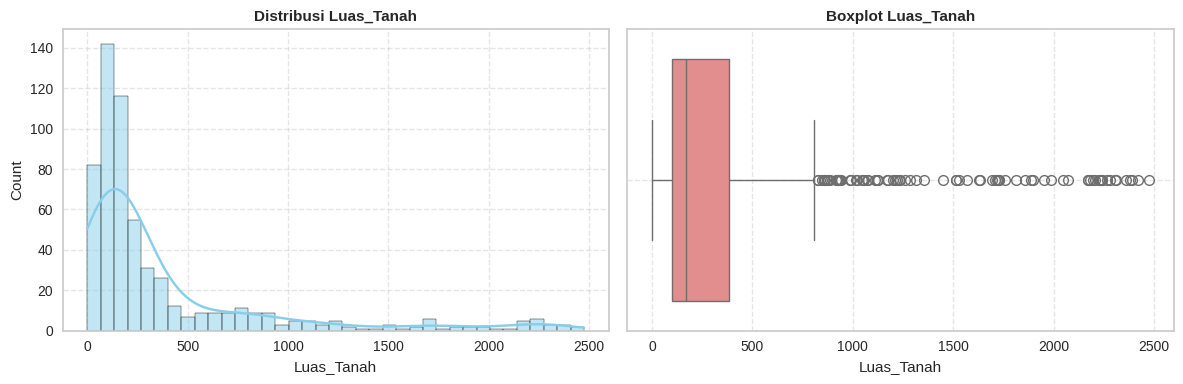

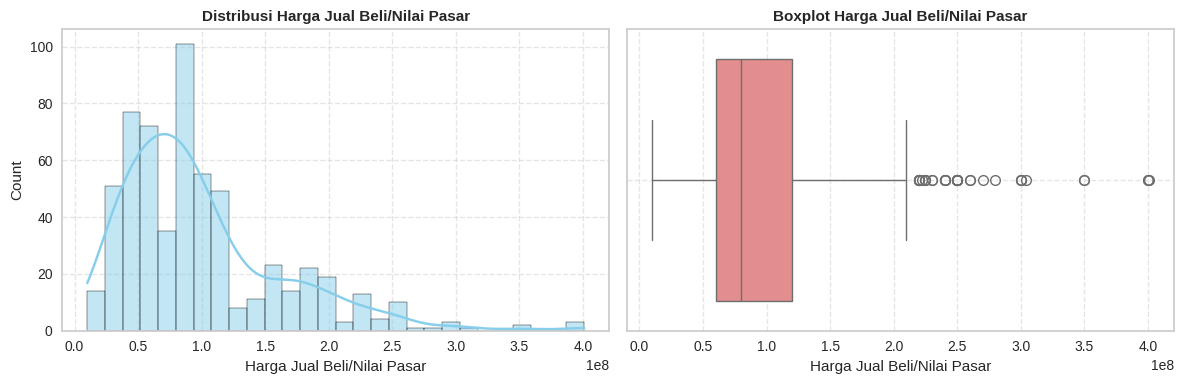

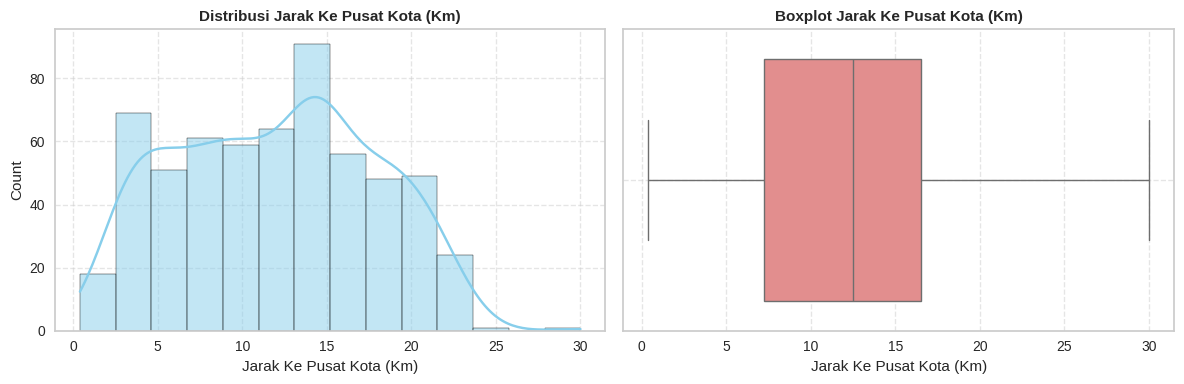

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. KONFIGURASI FITUR / KOLOM YANG AKAN DIVISUALISASIKAN
# =====================================================================
cols_to_plot = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']


# =====================================================================
# 2. PERULANGAN (LOOPING) PEMBUATAN GRAFIK ANALISIS OUTLIER
# =====================================================================
for col in cols_to_plot:
    # Membuat kanvas grafik dengan ukuran proporsional
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # A. Sub-plot 1: Histogram & Tren Distribusi Data (KDE)
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # B. Sub-plot 2: Boxplot untuk Deteksi Outlier (Pencilan)
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot {col}', fontsize=11, fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    # Merapikan tata letak antar sub-plot agar tidak saling bertumpang tindih
    plt.tight_layout()

    # Menampilkan grafik untuk kolom saat ini sebelum lanjut ke iterasi berikutnya
    plt.show()

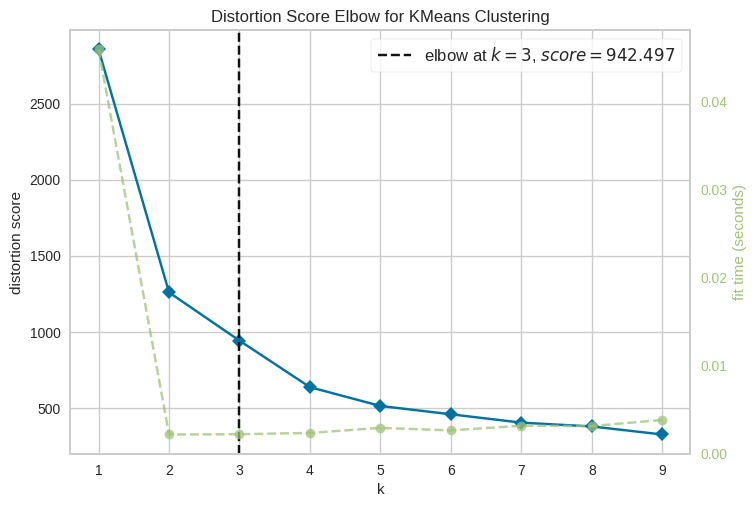

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from yellowbrick.cluster import KElbowVisualizer

# =====================================================================
# 1. PENGONDISIAN DATA (Load Data & Imputasi Missing Value)
# =====================================================================
try:
    df.head()
except NameError:
    # Mengunduh data jika dataframe 'df' belum ada di memori
    file_id = '19v6laLobOQlA0ATfxBRc4SnAZSqY_7Zo'
    download_url = f'https://drive.google.com/uc?id={file_id}'
    df = pd.read_excel(download_url)

    # Isi nilai yang hilang (missing value) dengan nilai Median
    cols_to_impute = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']
    for col in cols_to_impute:
        df[col] = df[col].fillna(df[col].median())

# =====================================================================
# 2. SELEKSI FITUR & TRANSFORMASI DATA (Feature Scaling)
# =====================================================================
# Menentukan fitur yang akan digunakan untuk clustering
features = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']

# Menggunakan RobustScaler agar skala data aman dari pengaruh outlier
scaler = RobustScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

# Mengambil nilai array dari fitur yang sudah di-scaling untuk model
X = df_scaled[features].values

# =====================================================================
# 3. PENENTUAN JUMLAH CLUSTER OPTIMAL (K-Elbow Method)
# =====================================================================
# Inisialisasi model KMeans dasar (tanpa jumlah cluster awal)
kmeans = KMeans(random_state=42, n_init='auto')

# Inisialisasi KElbowVisualizer untuk menguji rentang cluster K = 1 sampai 9
visualizer = KElbowVisualizer(kmeans, k=(1, 10))

# Melatih visualizer dengan data yang sudah bersih dan berskala
visualizer.fit(X)

# Menampilkan grafik elbow untuk menentukan nilai K terbaik
visualizer.show()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler

# =====================================================================
# 1. PENGAMBILAN & PENYIAPAN DATA
# =====================================================================
# Pengambilan dataset langsung dari Google Drive
file_id = '19v6laLobOQlA0ATfxBRc4SnAZSqY_7Zo'
download_url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_excel(download_url)

# Menentukan fitur/kolom spesifik yang akan digunakan untuk clustering
cols_to_use = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']


# =====================================================================
# 2. TRANSFORMASI DATA (Feature Scaling)
# =====================================================================
# Transformasi menggunakan RobustScaler agar skala data aman dari outlier
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[cols_to_use])


# =====================================================================
# 3. PEMODELAN K-MEANS CLUSTERING
# =====================================================================
# Menjalankan model KMeans dengan jumlah klaster optimal (k=4)
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)


# =====================================================================
# 4. EVALUASI MODEL (Silhouette Score)
# =====================================================================
# Acuan interpretasi nilai Silhouette Score:
# * Nilai > 0.5   -> Klasterisasi sangat bagus (struktur klaster kuat).
# * Nilai 0.3-0.5 -> Klasterisasi bisa diterima (struktur klaster moderat).
# * Nilai < 0.3   -> Klasterisasi kurang baik (klaster saling bertumpang tindih).

# Menghitung dan menampilkan performa kedekatan antar klaster
score = silhouette_score(X_scaled, cluster_labels)
print(f'Silhouette Score: {score:.3f}')


Silhouette Score: 0.479


Jumlah Klaster K=2 | Silhouette Score: 0.656
Jumlah Klaster K=3 | Silhouette Score: 0.479
Jumlah Klaster K=4 | Silhouette Score: 0.474
Jumlah Klaster K=5 | Silhouette Score: 0.359
Jumlah Klaster K=6 | Silhouette Score: 0.363
Jumlah Klaster K=7 | Silhouette Score: 0.355


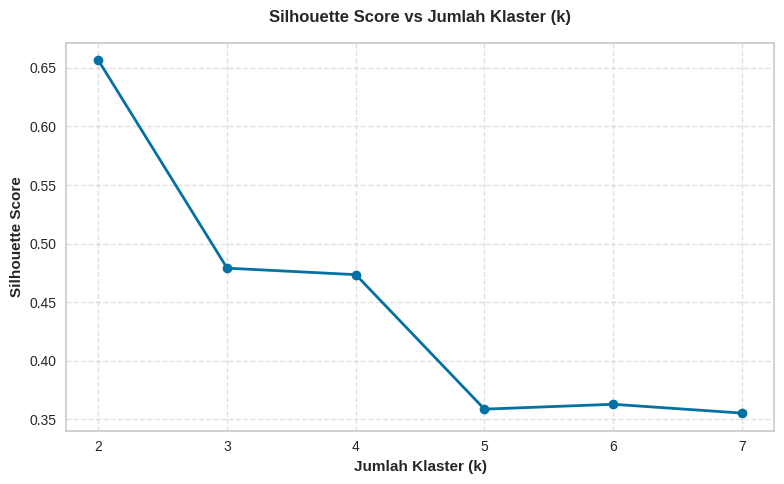

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =====================================================================
# 1. KONFIGURASI PENGUJIAN KLASTER (K)
# =====================================================================
# Menentukan rentang nilai k yang akan diuji (k = 2 sampai 7)
k_values = range(2, 8)
silhouette_scores = []

# =====================================================================
# 2. PERULANGAN (LOOPING) EVALUASI SILHOUETTE
# =====================================================================
for k in k_values:
    # Inisialisasi dan latih model KMeans untuk setiap nilai k
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Hitung nilai Silhouette Score lalu simpan ke dalam list
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    # Menampilkan log skor ke layar (opsional, untuk memantau proses)
    print(f"Jumlah Klaster K={k} | Silhouette Score: {score:.3f}")

# =====================================================================
# 3. VISUALISASI GRAFIK EVALUASI
# =====================================================================
plt.figure(figsize=(8, 5))

# Plot garis tren skor silhouette
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b', linewidth=2)

# Kustomisasi judul teks dan label sumbu grafik
plt.title('Silhouette Score vs Jumlah Klaster (k)', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Jumlah Klaster (k)', fontsize=11, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=11, fontweight='bold')

# Pengaturan grid, skala sumbu X, dan tata letak
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Tampilkan Grafik Akhir
plt.show()

In [ ]:
import numpy as np

# =====================================================================
# 4. K-MEANS MANUAL (Euclidean Distance Hingga Konvergen)
# =====================================================================

# 4a. Mengambil nilai K optimal secara otomatis dari grafik Elbow
# Jika Elbow tidak terdeteksi, kita gunakan nilai default (misal: 3)
K_optimal = visualizer.elbow_value_ if visualizer.elbow_value_ is not None else 3
print(f"Menggunakan Jumlah Cluster Optimal (K) = {K_optimal}\n")

# 4b. Inisialisasi Centroid Awal secara acak dari data poin X (agar objektif)
np.random.seed(42)  # Mengunci random state agar hasil konsisten dengan KMeans sklearn
random_indices = np.random.choice(X.shape[0], size=K_optimal, replace=False)
centroids = X[random_indices].copy()

print("--- CENTROID AWAL (Hasil Scaling) ---")
print(centroids)
print("-" * 50)

# 4c. Proses Iterasi K-Means Manual
konvergen = False
iterasi = 1
max_iterasi = 300  # Batas aman untuk mencegah loop tak terbatas

while not konvergen and iterasi <= max_iterasi:
    print(f"Iterasi ke-{iterasi}...")

    # 1. HITUNG JARAK EUCLIDEAN
    # X[:, np.newaxis] mengubah shape X menjadi (N, 1, Fitur)
    # Menghasilkan matriks jarak dengan dimensi (Jumlah Data x Jumlah Centroid)
    jarak_euclidean = np.sqrt(np.sum((X[:, np.newaxis] - centroids) ** 2, axis=2))

    # 2. ASSIGNMENT STEP (Menentukan kluster berdasarkan jarak terdekat/minimum)
    labels = np.argmin(jarak_euclidean, axis=1)

    # 3. UPDATE STEP (Menghitung centroid baru berdasarkan rata-rata anggota kluster)
    centroids_baru = np.zeros_like(centroids)
    for k in range(K_optimal):
        anggota_kluster = X[labels == k]

        # Antisipasi jika ada kluster yang kosong saat iterasi berjalan
        if len(anggota_kluster) > 0:
            centroids_baru[k] = anggota_kluster.mean(axis=0)
        else:
            # Jika kosong, tetap gunakan centroid lama atau pilih acak ulang
            centroids_baru[k] = centroids[k]

    # 4. CEK KONVERGENSI (Apakah posisi centroid sudah tidak bergeser?)
    # Menggunakan tolerance mendekati 0 untuk mengantisipasi error pembulatan tipe data float
    if np.allclose(centroids, centroids_baru, atol=1e-6):
        konvergen = True
        print(f"\n=> STATUS: KONVERGEN di iterasi ke-{iterasi}!")
        print("Centroid sudah stabil dan tidak berubah lagi.")
    else:
        centroids = centroids_baru.copy()
        iterasi += 1

print("-" * 50)
print("--- CENTROID AKHIR YANG KONVERGEN ---")
print(centroids)

# =====================================================================
# 5. INTEGRASI HASIL KE DATAFRAME ASLI
# =====================================================================
# Memasukkan hasil pelabelan cluster manual ke dataframe utama Anda
df['Cluster_Manual'] = labels
print(f"\nHasil kluster telah disimpan ke kolom 'Cluster_Manual' di dataframe 'df'.")

Menggunakan Jumlah Cluster Optimal (K) = 3

--- CENTROID AWAL (Hasil Scaling) ---
[[ 0.97302002 -0.33333333 -0.7027027 ]
 [ 0.15491732  0.83333333 -0.54054054]
 [ 3.34029591  0.          0.29189189]]
--------------------------------------------------
Iterasi ke-1...
Iterasi ke-2...
Iterasi ke-3...
Iterasi ke-4...
Iterasi ke-5...
Iterasi ke-6...
Iterasi ke-7...
Iterasi ke-8...
Iterasi ke-9...

=> STATUS: KONVERGEN di iterasi ke-9!
Centroid sudah stabil dan tidak berubah lagi.
--------------------------------------------------
--- CENTROID AKHIR YANG KONVERGEN ---
[[ 0.2196459  -0.18092065 -0.0383673 ]
 [ 0.06978451  1.91134259 -0.21501502]
 [ 5.3290508   1.54031746  0.05336765]]

Hasil kluster telah disimpan ke kolom 'Cluster_Manual' di dataframe 'df'.


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
# Fit model
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X_scaled)
# Simpan hasil klaster ke dataframe
df['Cluster'] = kmeans.labels_

In [ ]:
df.groupby('Cluster')[features].mean().round(0)

,Luas_Tanah,Harga Jual Beli/Nilai Pasar,Jarak Ke Pusat Kota (Km)
Cluster,,,
0,156.0,82712198.0,12.0
1,1993.0,193107317.0,14.0
2,761.0,137361979.0,12.0


In [ ]:
# =====================================================================
# 6. ANALISIS DESKRIPTIF PROFIL CLUSTER (Min, Max, Mean)
# =====================================================================

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

# --- Pastikan `df` dan `features` sudah terdefinisi ---
# Jika sel ini dijalankan secara independen, kode di bawah akan memastikan 'df' tersedia.
# Jika Anda yakin 'df' dan 'features' sudah ada dari sel sebelumnya, Anda bisa menghapus bagian ini.

# PENGAMBILAN DATA & IMPUTASI (Data Preparation)
file_id = '19v6laLobOQlA0ATfxBRc4SnAZSqY_7Zo'
download_url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_excel(download_url)

features = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']

for col in features:
    df[col] = df[col].fillna(df[col].median())

# TRANSFORMASI DATA (Feature Scaling)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[features])

# PEMODELAN K-MEANS CLUSTERING (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
raw_cluster_labels = kmeans.fit_predict(X_scaled)
df['Tmp_Cluster'] = raw_cluster_labels

# RE-INDEXING & MAPPING KLASTER (Sorting Berdasarkan Harga)
target_col = 'Harga Jual Beli/Nilai Pasar'
ordered_clusters = df.groupby('Tmp_Cluster')[target_col].mean().sort_values().index
cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(ordered_clusters)}
df['Cluster'] = df['Tmp_Cluster'].map(cluster_mapping)
df.drop(columns=['Tmp_Cluster'], inplace=True)

# --------------------------------------------------------

print("--- PROFILING CLUSTER: NILAI MIN, MAX, DAN MEAN ---")

# 1. Mengelompokkan data berdasarkan Cluster (K-Means Sklearn)
# Jika ingin menggunakan hasil manual, ganti 'Cluster' menjadi 'Cluster_Manual'
cluster_profile = df.groupby('Cluster')[features].agg(['min', 'max', 'mean'])

# 2. Membulatkan nilai agar lebih mudah dibaca (misalnya 2 angka di belakang koma)
cluster_profile = cluster_profile.round(2)

# 3. Menampilkan hasil ke layar
# Menggunakan pd.option_context untuk memastikan semua kolom terlihat jika fitur cukup banyak
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(cluster_profile)

print("-" * 50)

--- PROFILING CLUSTER: NILAI MIN, MAX, DAN MEAN ---
        Luas_Tanah                  Harga Jual Beli/Nilai Pasar                          Jarak Ke Pusat Kota (Km)             
               min     max     mean                         min        max          mean                      min   max   mean
Cluster                                                                                                                       
0             1.01   545.0   155.85                    10000000  304500000  8.271220e+07                      0.4  23.2  11.78
1             2.00  1357.0   761.28                    40000000  401000000  1.373620e+08                      2.0  30.0  12.21
2          1447.00  2474.0  1992.66                   100000000  300000000  1.931073e+08                      3.9  21.7  13.73
--------------------------------------------------


In [ ]:
# =====================================================================
# 7. MENGHITUNG JUMLAH DATA DAN PERSENTASE TIAP CLUSTER
# =====================================================================

print("\n--- DISTRIBUSI / JUMLAH ANGGOTA TIAP CLUSTER ---")

# 1. Menghitung jumlah total data di setiap cluster
cluster_counts = df['Cluster'].value_counts().sort_index()

# 2. Menghitung persentase kontribusi setiap cluster terhadap total data
cluster_percentages = (df['Cluster'].value_counts(normalize=True) * 100).sort_index()

# 3. Menggabungkan jumlah dan persentase ke dalam satu DataFrame yang rapi
cluster_distribution = pd.DataFrame({
    'Jumlah Anggota': cluster_counts,
    'Persentase (%)': cluster_percentages.round(2)
})

# 4. Mengubah nama index agar lebih informatif saat dicetak
cluster_distribution.index.name = 'Cluster'

# 5. Menampilkan hasil ke layar
print(cluster_distribution)
print(f"\nTotal Keseluruhan Data: {df.shape[0]} baris")
print("-" * 50)



--- DISTRIBUSI / JUMLAH ANGGOTA TIAP CLUSTER ---
         Jumlah Anggota  Persentase (%)
Cluster                                
0                   455           76.86
1                    96           16.22
2                    41            6.93

Total Keseluruhan Data: 592 baris
--------------------------------------------------


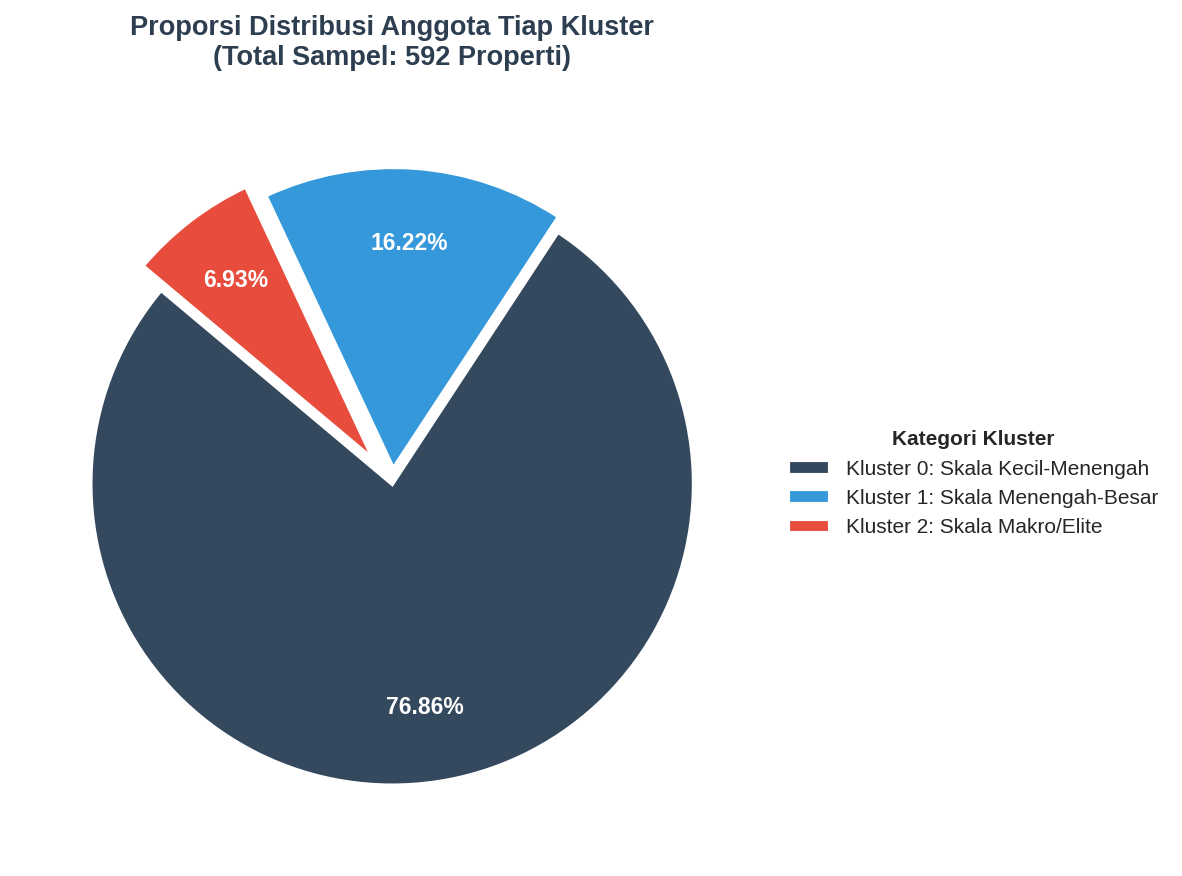

In [ ]:
import matplotlib.pyplot as plt

# =====================================================================
# 8. VISUALISASI DISTRIBUSI KLASTER (ESTETIC PIE CHART)
# =====================================================================

# 1. Menyiapkan data berdasarkan hasil distribusi sebelumnya
labels = ['Kluster 0: Skala Kecil-Menengah',
          'Kluster 1: Skala Menengah-Besar',
          'Kluster 2: Skala Makro/Elite']
sizes = [455, 96, 41]

# 2. Pengaturan estetika grafik
# Menggunakan palet warna modern yang kontras namun tetap profesional
colors = ['#34495e', '#3498db', '#e74c3c']

# Memberikan efek sedikit renggang (explode) pada kluster minoritas agar menonjol
explode = (0, 0.05, 0.1)

# 3. Membuat objek visualisasi
plt.figure(figsize=(9, 6), dpi=150) # Resolusi tinggi (dpi=150) agar tajam saat dicetak

# Menggambar Pie Chart
wedges, texts, autotexts = plt.pie(
    sizes,
    explode=explode,
    labels=None,            # Label teks dipindah ke Legend agar grafik bersih
    autopct='%1.2f%%',     # Menampilkan 2 angka di belakang koma
    startangle=140,         # Memutar sudut mulai agar komposisi seimbang
    colors=colors,
    shadow=False,           # Tanpa shadow agar terlihat modern (flat design)
    pctdistance=0.75,       # Mengatur posisi teks persentase di dalam lingkaran
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Garis pembatas putih yang bersih
)

# 4. Mempercantik font persentase di dalam lingkaran
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

# 5. Menambahkan Legend (Keterangan) dan Judul yang Informatif
plt.legend(
    wedges,
    labels,
    title="Kategori Kluster",
    title_fontproperties={'weight': 'bold', 'size': 10},
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1) # Menggeser kotak keterangan ke luar kanan grafik
)

plt.title('Proporsi Distribusi Anggota Tiap Kluster\n(Total Sampel: 592 Properti)',
          fontsize=13,
          pad=20,
          fontweight='bold',
          color='#2c3e50')

# 6. Menampilkan dan menyimpan grafik
plt.tight_layout()
plt.show()


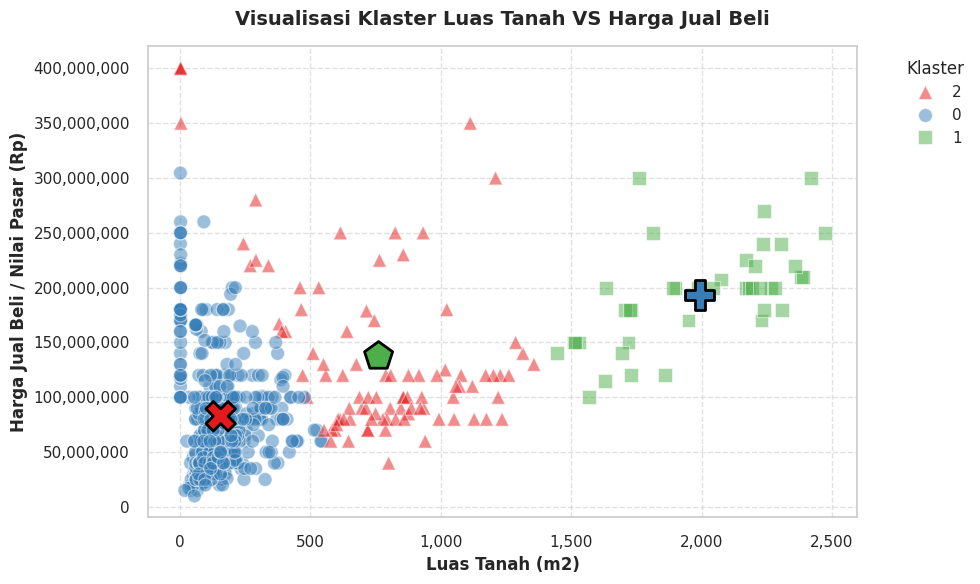

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

# =====================================================================
# 1. PENGECEKAN DATA & PEMODELAN K-MEANS
# =====================================================================
# Lakukan klasterisasi jika kolom 'Cluster' belum ada di dalam DataFrame
if 'Cluster' not in df.columns:
    # A. Membaca & Mengunduh Data
    file_id = '19v6laLobOQlA0ATfxBRc4SnAZSqY_7Zo'
    download_url = f'https://drive.google.com/uc?id={file_id}'
    df = pd.read_excel(download_url)

    # B. Imputasi Missing Value dengan Median
    cols_to_use = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']
    for col in cols_to_use:
        df[col] = df[col].fillna(df[col].median())

    # C. Transformasi Skala Data (RobustScaler)
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(df[cols_to_use])

    # D. Clustering K-Means (k=3)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
    df['Tmp_Cluster'] = kmeans.fit_predict(X_scaled)

    # E. Mengurutkan Klaster Berdasarkan Rata-Rata Harga Jual Beli
    target_col = 'Harga Jual Beli/Nilai Pasar'
    ordered_clusters = df.groupby('Tmp_Cluster')[target_col].mean().sort_values().index

    # Membuat mapping urutan klaster baru (0, 1, 2, 3)
    cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(ordered_clusters)}
    df['Cluster'] = df['Tmp_Cluster'].map(cluster_mapping)

    # Menghapus kolom klaster sementara
    df.drop(columns=['Tmp_Cluster'], inplace=True)


# =====================================================================
# 2. PREPARASI DATA VISUALISASI
# =====================================================================
# Mengubah tipe klaster ke string agar penanganan warna di grafik lebih rapi
df['Cluster'] = df['Cluster'].astype(str)

# Menghitung posisi koordinat Centroid (rata-rata) tiap klaster
centroids = df.groupby('Cluster')[['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar']].mean().reset_index()

# Menentukan bentuk penanda (markers) yang berbeda untuk data dan centroid
data_markers = {'0': 'o', '1': 's', '2': '^', '3': 'D'}        # Lingkaran, Kotak, Segitiga, Wajik
centroid_markers = {'0': 'X', '1': 'P', '2': 'p', '3': '*'}    # Silang, Plus, Segilima, Bintang


# =====================================================================
# 3. PEMBUATAN GRAFIK SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# A. Plot Titik Data Properti
sns.scatterplot(
    data=df,
    x='Luas_Tanah',
    y='Harga Jual Beli/Nilai Pasar',
    hue='Cluster',
    style='Cluster',
    markers=data_markers,
    palette='Set1',
    s=100,
    alpha=0.5,
    ax=ax
)

# B. Plot Titik Centroid (Ukuran Besar & Lapisan Paling Atas)
sns.scatterplot(
    data=centroids,
    x='Luas_Tanah',
    y='Harga Jual Beli/Nilai Pasar',
    hue='Cluster',
    style='Cluster',
    markers=centroid_markers,
    palette='Set1',
    s=450,
    edgecolor='black',
    linewidth=2,
    zorder=5,
    legend=False,
    ax=ax
)


# =====================================================================
# 4. KUSTOMISASI TAMPILAN GRAFIK (Formatting & Labeling)
# =====================================================================
# Kustomisasi teks Judul dan Sumbu (Label)
plt.title('Visualisasi Klaster Luas Tanah VS Harga Jual Beli', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Luas Tanah (m2)', fontsize=12, fontweight='bold')
plt.ylabel('Harga Jual Beli / Nilai Pasar (Rp)', fontsize=12, fontweight='bold')

# Memformat tampilan angka sumbu X dan Y dengan pemisah ribuan (koma)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Mengatur tata letak legenda, grid, dan margins
plt.legend(title='Klaster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Tampilkan Grafik Akhir
plt.show()

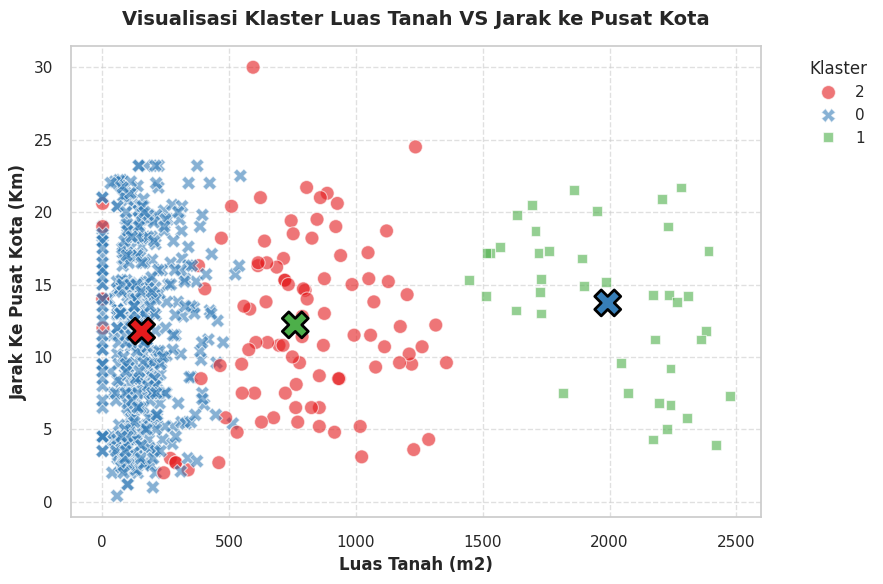

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PREPARASI DATA VISUALISASI
# =====================================================================
# Mengubah tipe klaster ke string agar penanganan warna di grafik lebih rapi
df['Cluster'] = df['Cluster'].astype(str)

# Menghitung posisi koordinat Centroid (rata-rata X dan Y) tiap klaster
centroids = df.groupby('Cluster')[['Luas_Tanah', 'Jarak Ke Pusat Kota (Km)']].mean().reset_index()


# =====================================================================
# 2. PEMBUATAN GRAFIK SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 6))

# A. Plot Semua Titik Data Properti
sns.scatterplot(
    data=df,
    x='Luas_Tanah',
    y='Jarak Ke Pusat Kota (Km)',
    hue='Cluster',
    style='Cluster',     # Memberikan bentuk titik berbeda untuk tiap klaster data
    palette='Set1',
    s=100,
    alpha=0.6,
    ax=ax
)

# B. Plot Titik Centroid (Ukuran Besar, Lapisan Atas & Penanda Khusus 'X')
sns.scatterplot(
    data=centroids,
    x='Luas_Tanah',
    y='Jarak Ke Pusat Kota (Km)',
    hue='Cluster',
    palette='Set1',
    marker='X',          # PERBAIKAN: Menggunakan satu bentuk 'X' raksasa untuk semua centroid
    s=350,
    edgecolor='black',
    linewidth=2,
    zorder=5,            # Memastikan centroid digambar di atas titik data (tidak tertimbun)
    legend=False,        # Sembunyikan legenda kedua agar tidak double
    ax=ax
)


# =====================================================================
# 3. KUSTOMISASI TAMPILAN GRAFIK (Formatting & Labeling)
# =====================================================================
# Kustomisasi teks Judul dan Sumbu (Label)
plt.title('Visualisasi Klaster Luas Tanah VS Jarak ke Pusat Kota', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Luas Tanah (m2)', fontsize=12, fontweight='bold')
plt.ylabel('Jarak Ke Pusat Kota (Km)', fontsize=12, fontweight='bold')

# Mengatur tata letak legenda, grid, dan margins
plt.legend(title='Klaster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Tampilkan Grafik Akhir
plt.show()

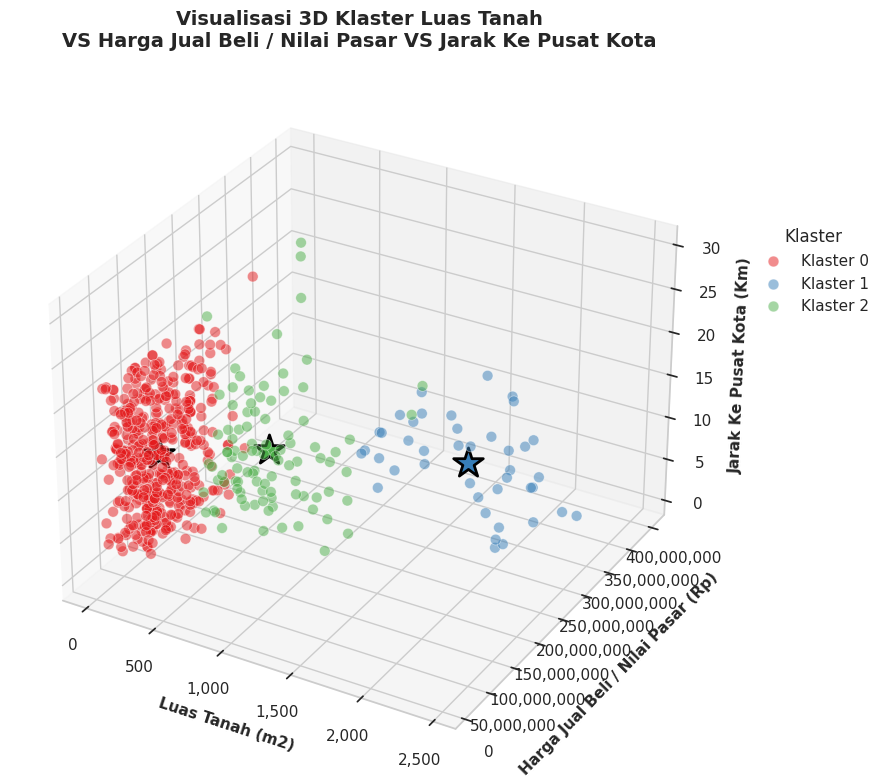

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # Modul wajib untuk proyeksi 3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

# =====================================================================
# 1. PENGECEKAN DATA & PEMODELAN K-MEANS
# =====================================================================
# Lakukan klasterisasi jika kolom 'Cluster' belum ada di dalam DataFrame
if 'Cluster' not in df.columns:
    # A. Membaca & Mengunduh Data
    file_id = '19v6laLobOQlA0ATfxBRc4SnAZSqY_7Zo'
    download_url = f'https://drive.google.com/uc?id={file_id}'
    df = pd.read_excel(download_url)

    # B. Imputasi Missing Value dengan Median
    cols_to_use = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']
    for col in cols_to_use:
        df[col] = df[col].fillna(df[col].median())

    # C. Transformasi Skala Data (RobustScaler)
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(df[cols_to_use])

    # D. Clustering K-Means (k=3)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
    df['Tmp_Cluster'] = kmeans.fit_predict(X_scaled)

    # E. Mengurutkan Klaster Berdasarkan Rata-Rata Harga Jual Beli
    target_col = 'Harga Jual Beli/Nilai Pasar'
    ordered_clusters = df.groupby('Tmp_Cluster')[target_col].mean().sort_values().index

    # Membuat mapping urutan klaster baru (0, 1, 2, 3)
    cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(ordered_clusters)}
    df['Cluster'] = df['Tmp_Cluster'].map(cluster_mapping)

    # Menghapus kolom klaster sementara
    df.drop(columns=['Tmp_Cluster'], inplace=True)


# =====================================================================
# 2. PREPARASI DATA VISUALISASI 3D
# =====================================================================
# Mengubah tipe klaster ke string agar penanganan warna di grafik lebih rapi
df['Cluster'] = df['Cluster'].astype(str)

# Menghitung posisi koordinat Centroid untuk ketiga variabel sekaligus
features_3d = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']
centroids = df.groupby('Cluster')[features_3d].mean().reset_index()

# Membuat pemetaan warna (color mapping) yang konsisten untuk tiap klaster
cluster_labels = sorted(df['Cluster'].unique())
colors = sns.color_palette('Set1', n_colors=len(cluster_labels))
color_mapping = dict(zip(cluster_labels, colors))


# =====================================================================
# 3. INISIALISASI KANVAS & PEMBUATAN GRAFIK 3D
# =====================================================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# A. Plot Titik Data Properti Properti Asli di Ruang 3D
for cluster in cluster_labels:
    df_subset = df[df['Cluster'] == cluster]
    ax.scatter(
        df_subset['Luas_Tanah'],
        df_subset['Harga Jual Beli/Nilai Pasar'],
        df_subset['Jarak Ke Pusat Kota (Km)'],
        color=color_mapping[cluster],
        label=f'Klaster {cluster}',
        s=60,
        alpha=0.5,
        edgecolors='w',
        linewidth=0.5
    )

# B. Plot Titik Centroid Bintang Raksasa (zorder=10 agar selalu di atas)
for cluster in cluster_labels:
    centroid_subset = centroids[centroids['Cluster'] == cluster]
    ax.scatter(
        centroid_subset['Luas_Tanah'],
        centroid_subset['Harga Jual Beli/Nilai Pasar'],
        centroid_subset['Jarak Ke Pusat Kota (Km)'],
        color=color_mapping[cluster],
        marker='*',
        s=500,
        edgecolor='black',
        linewidth=2,
        zorder=10
    )


# =====================================================================
# 4. KUSTOMISASI TAMPILAN GRAFIK (Formatting & Labeling)
# =====================================================================
# Kustomisasi Judul Grafik (Perbaikan typo: Pusat Kota)
plt.title('Visualisasi 3D Klaster Luas Tanah\nVS Harga Jual Beli / Nilai Pasar VS Jarak Ke Pusat Kota', fontsize=14, pad=20, fontweight='bold')

# Kustomisasi Label Sumbu X, Y, dan Z beserta jaraknya (pad)
ax.set_xlabel('Luas Tanah (m2)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Harga Jual Beli / Nilai Pasar (Rp)', fontsize=11, fontweight='bold', labelpad=15)
ax.set_zlabel('Jarak Ke Pusat Kota (Km)', fontsize=11, fontweight='bold', labelpad=10)

# Memformat tampilan angka sumbu X dan Y dengan pemisah ribuan (koma)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Mengatur posisi kotak keterangan (legenda) dan margin kanvas
ax.legend(title='Klaster', bbox_to_anchor=(1.05, 0.8), loc='upper left')
plt.tight_layout()

# Pengaturan sudut pandang kamera awal (Opsional - buka tanda pagar jika ingin digunakan)
# ax.view_init(elev=20, azim=45)

# Tampilkan Grafik Akhir
plt.show()

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler

# =====================================================================
# 1. PENGAMBILAN DATA & IMPUTASI (Data Preparation)
# =====================================================================
# Mengunduh dataset langsung dari Google Drive
file_id = '19v6laLobOQlA0ATfxBRc4SnAZSqY_7Zo'
download_url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_excel(download_url)

# Menentukan fitur/kolom spesifik yang akan digunakan untuk analisis
features = ['Luas_Tanah', 'Harga Jual Beli/Nilai Pasar', 'Jarak Ke Pusat Kota (Km)']

# Mengisi nilai yang hilang (missing value) menggunakan nilai Median
for col in features:
    df[col] = df[col].fillna(df[col].median())

# =====================================================================
# 2. TRANSFORMASI DATA (Feature Scaling)
# =====================================================================
# Transformasi menggunakan RobustScaler agar skala data aman dari outlier
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[features])

# =====================================================================
# 3. PEMODELAN K-MEANS CLUSTERING (k=3)
# =====================================================================
# Menginisialisasi dan melatih model KMeans dasar
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
raw_cluster_labels = kmeans.fit_predict(X_scaled)

# Menyimpan label klaster mentah ke dalam kolom sementara
df['Tmp_Cluster'] = raw_cluster_labels

# =====================================================================
# 4. RE-INDEXING & MAPPING KLASTER (Sorting Berdasarkan Harga)
# =====================================================================
# Menghitung rata-rata harga untuk setiap klaster, lalu diurutkan dari terkecil
target_col = 'Harga Jual Beli/Nilai Pasar'
ordered_clusters = df.groupby('Tmp_Cluster')[target_col].mean().sort_values().index

# Membuat kamus (mapping) untuk mengubah label lama ke label baru (0, 1, 2, 3)
cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(ordered_clusters)}

# Menerapkan label baru yang berurutan ke kolom 'Cluster' utama
df['Cluster'] = df['Tmp_Cluster'].map(cluster_mapping)

# Menghapus kolom klaster sementara agar DataFrame tetap bersih
df.drop(columns=['Tmp_Cluster'], inplace=True)

# =====================================================================
# 5. MENAMPILKAN HASIL AKHIR
# =====================================================================
# Menampilkan 5 baris pertama data hasil klasterisasi
df.head()

,No,Nama Pemegang Hak,No Hak,Letak Desa,Letak Kecamatan,Luas_Tanah,Harga Jual Beli/Nilai Pasar,Jarak Ke Pusat Kota (Km),Cluster
0,1,TEGUH WIYANTO,358,Balerante,Kemalang,595.0,70000000,30.0,1
1,2,DWI YULIE MAHFUDZ NURJANAH,1044,Karangpakel,Trucuk,175.0,60000000,10.7,0
2,3,SUMARDI,802,Kedungan,Pedan,140.0,110000000,12.2,0
3,4,ANDRE KURNIAWAN,2468,Candirejo,Ngawen,281.0,85000000,5.2,0
4,5,WINDARTI,6372,Jimbung,Kalikotes,108.0,70000000,5.8,0


In [ ]:
import joblib

# Menyimpan model K-Means dan Scaler ke dalam file lokal
joblib.dump(kmeans, 'model_kmeans.pkl')
joblib.dump(scaler, 'scaler_robust.pkl')

print("Model dan Scaler berhasil diekspor!")


Model dan Scaler berhasil diekspor!


In [ ]:
import os
import joblib

# Pastikan variabel 'kmeans' dan 'scaler' sudah Anda buat & latih di baris sebelum ini!
try:
    # 1. Menyimpan model K-Means dan Scaler ke folder aktif saat ini
    joblib.dump(kmeans, 'model_kmeans.pkl')
    joblib.dump(scaler, 'scaler_robust.pkl')

    print("✨ Model dan Scaler berhasil diekspor!")
    print(f"📁 Lokasi penyimpanan: {os.getcwd()}")
    print("📄 File yang terbentuk: 'model_kmeans.pkl' & 'scaler_robust.pkl'")

except NameError as e:
    print(f"❌ Error: Variabel belum siap. {e}")
    print("💡 Pastikan Anda sudah menjalankan proses training/fitting untuk kmeans dan scaler sebelum baris ini.")
except Exception as e:
    print(f"❌ Terjadi kesalahan saat menyimpan file: {e}")


✨ Model dan Scaler berhasil diekspor!
📁 Lokasi penyimpanan: /content
📄 File yang terbentuk: 'model_kmeans.pkl' & 'scaler_robust.pkl'
